# Signal Respirometry — Project Setup

This notebook bootstraps a standard structure for data analysis:

- `data/` — raw, processed, and external data
- `figures/` — generated plots and exports
- `video/` — raw videos and derived clips
- `notebooks/` — analysis notebooks (this file)

It also performs a quick environment check, ensures directories exist, and creates a demo plot in `figures/`.

In [1]:
# Imports with friendly fallbacks
from pathlib import Path
import sys, platform


def soft_import(name):
    try:
        return __import__(name)
    except ImportError:
        print(f"Optional package '{name}' not found. You can install it with: pip install {name}")
        return None

np = soft_import('numpy')
pd = soft_import('pandas')
plt_mod = soft_import('matplotlib.pyplot')
cv2 = soft_import('cv2')
plt = plt_mod if plt_mod is not None else None

print('Python:', sys.version.split()[0])
print('Platform:', platform.platform())
print('Numpy:', getattr(np, '__version__', 'not installed'))
print('Pandas:', getattr(pd, '__version__', 'not installed'))
print('Matplotlib:', getattr(plt_mod, '__version__', 'not installed'))
print('OpenCV:', getattr(cv2, '__version__', 'not installed'))

Python: 3.8.15
Platform: macOS-15.5-arm64-arm-64bit
Numpy: 1.24.2
Pandas: 2.0.1
Matplotlib: 3.3.3
OpenCV: 4.7.0


In [2]:
# Project paths
ROOT = Path('..').resolve()  # This notebook lives in notebooks/
DATA_DIR = ROOT / 'data'
FIGURES_DIR = ROOT / 'figures'
VIDEO_DIR = ROOT / 'video'
NOTEBOOKS_DIR = ROOT / 'notebooks'

# Optional sub-structure under data/
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
EXTERNAL_DIR = DATA_DIR / 'external'

for p in [DATA_DIR, FIGURES_DIR, VIDEO_DIR, NOTEBOOKS_DIR, RAW_DIR, PROCESSED_DIR, EXTERNAL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('ROOT      =', ROOT)
print('DATA_DIR  =', DATA_DIR)
print('FIGURES   =', FIGURES_DIR)
print('VIDEO     =', VIDEO_DIR)

ROOT      = /Users/oakley/Documents/GitHub/signal_respirometry
DATA_DIR  = /Users/oakley/Documents/GitHub/signal_respirometry/data
FIGURES   = /Users/oakley/Documents/GitHub/signal_respirometry/figures
VIDEO     = /Users/oakley/Documents/GitHub/signal_respirometry/video


## List videos in `video/`

This cell lists video files in the `video/` folder (non-recursive by default, configurable), without generating thumbnails or reading frames.

In [3]:
# List videos
from pathlib import Path
from datetime import datetime
import os

# Ensure VIDEO_DIR is defined even if this cell is run standalone
try:
    VIDEO_DIR
except NameError:
    ROOT = Path('..').resolve()
    VIDEO_DIR = ROOT / 'video'

# Configure
extensions = ['.mp4', '.mov', '.avi', '.mkv', '.m4v', '.wmv']
recursive = False  # set True to search subfolders

scan_iter = (VIDEO_DIR.rglob('*') if recursive else VIDEO_DIR.iterdir())
rows = []
for p in scan_iter:
    if p.is_file() and p.suffix.lower() in extensions:
        size = p.stat().st_size
        mtime = datetime.fromtimestamp(p.stat().st_mtime)
        rows.append({
            'name': p.name,
            'path': str(p),
            'size_bytes': size,
            'size_mb': round(size / (1024*1024), 2),
            'modified': mtime.strftime('%Y-%m-%d %H:%M:%S')
        })

if len(rows) == 0:
    print(f'No video files found in {VIDEO_DIR} (recursive={recursive}).')
else:
    try:
        import pandas as pd
        df = pd.DataFrame(rows).sort_values('name').reset_index(drop=True)
        display(df)
        print(f"Found {len(df)} video(s).")
    except Exception:
        for r in sorted(rows, key=lambda r: r['name']):
            print(f"{r['name']}\t{r['size_mb']} MB\t{r['modified']}")
        print(f"Found {len(rows)} video(s).")

,name,path,size_bytes,size_mb,modified
0,GX010063.MP4,/Users/oakley/Documents/GitHub/signal_respirom...,70152712,66.90,2025-11-10 19:32:01
1,GX010065.MP4,/Users/oakley/Documents/GitHub/signal_respirom...,28445571,27.13,2025-11-11 18:58:33
2,GX010067.MP4,/Users/oakley/Documents/GitHub/signal_respirom...,225860963,215.40,2025-11-13 07:32:51
3,GX010069.MP4,/Users/oakley/Documents/GitHub/signal_respirom...,84760382,80.83,2025-11-13 07:49:45
4,GX010070.MP4,/Users/oakley/Documents/GitHub/signal_respirom...,5269942,5.03,2025-11-13 18:21:38
5,GX010071.MP4,/Users/oakley/Documents/GitHub/signal_respirom...,5472842,5.22,2025-11-13 18:21:45
6,GX010072.MP4,/Users/oakley/Documents/GitHub/signal_respirom...,158627374,151.28,2025-11-14 07:50:54


Found 7 video(s).


## Playback sanity check (record of command)

This is the exact command used for quick visual inspection at half resolution with hotspots masked via inpainting:

```zsh
conda run -n walle python scripts/play_blue_channel.py \
  --mask-in data/processed/GX010063_hotmask.png \
  --mask-mode inpaint \
  --inpaint-radius 2 \
  --scale 0.5
```

Tip: The code cell below runs the same settings directly from the notebook and should open an external window. Use q or ESC to exit, SPACE to pause.

In [4]:
# Run playback sanity check (opens a window)
from pathlib import Path
import sys
import subprocess

# Resolve paths from notebook location
ROOT = Path('..').resolve()
script = ROOT / 'scripts' / 'play_blue_channel.py'
mask = ROOT / 'data' / 'processed' / 'GX010063_hotmask.png'

cmd = [
    sys.executable,  # use the current kernel's Python (walle)
    str(script),
    '--mask-in', str(mask),
    '--mask-mode', 'inpaint',
    '--inpaint-radius', '2',
    '--scale', '0.5',
]

print('Running:', ' '.join(cmd))
print('Note: Close the video window with q or ESC. Space pauses/resumes.')
# Stream output; this will block until you close the window
ret = subprocess.run(cmd)
print('Exit code:', ret.returncode)

Running: /opt/homebrew/Caskroom/miniforge/base/envs/walle/bin/python /Users/oakley/Documents/GitHub/signal_respirometry/scripts/play_blue_channel.py --mask-in /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010063_hotmask.png --mask-mode inpaint --inpaint-radius 2 --scale 0.5
Note: Close the video window with q or ESC. Space pauses/resumes.
Opened: /Users/oakley/Documents/GitHub/signal_respirometry/video/GX010063.MP4
Resolution: 3840x2160  FPS: 29.97  Frames: 337
Playback target FPS: 29.97  frame_budget_ms: 33
Loaded hotspot mask from /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010063_hotmask.png  (nonzero=141205)
Exit code: 0


## Quantification kickoff: detect blue streaks

We start a simple contour-based detector that thresholds the blue channel, filters small areas, and writes centroids per frame to CSV. Command recorded here for provenance:

```zsh
conda run -n walle python scripts/analyze_streaks.py \
  --mask-in data/processed/GX010063_hotmask.png \
  --scale 0.5 \
  --max-frames 120
```

Run the same from this notebook below (writes to `data/processed/GX010063_streaks.csv`).

In [25]:
# Extract all contours across the entire video and find the best frame for ROI selection
from pathlib import Path
import sys, subprocess, io
import pandas as pd

# Configure video and analysis scale
video_name = "GX010063.MP4"  # change as needed
analyze_scale = 0.5           # detection scale; coordinates saved at this scale
blue_thresh = 100            # set to an int (e.g., 180-220) to force fixed threshold; None = Otsu
blur_ksize = 3                # odd kernel size (3,5,7), or 0 to disable
min_area = 5                 # filter small speckles (at scaled resolution)
use_bminusg = True            # emphasize blue dominance (B-G) to suppress non-blue

# Paths
ROOT = Path('..').resolve()
VIDEO_DIR = ROOT / 'video'
DATA_DIR = ROOT / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
video_path = VIDEO_DIR / video_name
an_script = ROOT / 'scripts' / 'analyze_streaks.py'
mask_path = PROCESSED_DIR / f"{video_path.stem}_hotmask.png"
csv_path = PROCESSED_DIR / f"{video_path.stem}_streaks.csv"

# Run analyzer over the entire video (no --max-frames, no ROI)
cmd = [
    sys.executable,
    str(an_script),
    '--video', str(video_path),
    '--output', str(csv_path),
    '--scale', str(analyze_scale),
    '--blur-ksize', str(blur_ksize),
    '--min-area', str(min_area),
]
if use_bminusg:
    cmd += ['--use-bminusg']
if blue_thresh is not None:
    cmd += ['--blue-thresh', str(int(blue_thresh))]
# Include mask if it exists
if mask_path.exists():
    cmd += ['--mask-in', str(mask_path)]
print('Command:', ' '.join(cmd))
ret = subprocess.run(cmd, capture_output=True, text=True)
print(ret.stdout)
if ret.stderr:
    print('stderr:\n', ret.stderr)
print('Wrote detections to:', csv_path)

# Load CSV (skip metadata preamble) and compute best frame (max contours)
with open(csv_path, 'r') as f:
    lines = f.readlines()
# find data header
header_idx = 0
for i, line in enumerate(lines[:100]):
    if line.lower().startswith('frame,'):
        header_idx = i
        break

df = pd.read_csv(io.StringIO(''.join(lines[header_idx:])))
per_frame = df.groupby('frame').size().rename('count').reset_index()
if len(per_frame) == 0:
    raise RuntimeError('No detections found; check thresholds/scale settings.')

best_row = per_frame.loc[per_frame['count'].idxmax()]
best_frame_index = int(best_row['frame'])
best_count = int(best_row['count'])
print(f'Best frame for ROI selection: frame {best_frame_index} with {best_count} contours')
print('You can re-run ROI selection using this frame index in the next cell.')

Command: /opt/homebrew/Caskroom/miniforge/base/envs/walle/bin/python /Users/oakley/Documents/GitHub/signal_respirometry/scripts/analyze_streaks.py --video /Users/oakley/Documents/GitHub/signal_respirometry/video/GX010063.MP4 --output /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010063_streaks.csv --scale 0.5 --blur-ksize 3 --min-area 5 --use-bminusg --blue-thresh 100 --mask-in /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010063_hotmask.png
Done. Wrote detections to /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010063_streaks.csv

Wrote detections to: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010063_streaks.csv
Best frame for ROI selection: frame 256 with 14 contours
You can re-run ROI selection using this frame index in the next cell.
Done. Wrote detections to /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010063_streaks.csv

Wrote detections to: /Users/oakley/Documents/Gi

In [30]:
# Preview the top-N frames with most contours and overlay detections (interactive)
from pathlib import Path
import sys, subprocess

# Configure
top_n = 10
video_name = video_name  # reuse from above
csv_path = PROCESSED_DIR / f"{Path(video_name).stem}_streaks.csv"
viewer_script = ROOT / 'scripts' / 'preview_top_contours.py'

cmd = [
    sys.executable,
    str(viewer_script),
    '--video', str(VIDEO_DIR / video_name),
    '--csv', str(csv_path),
    '--scale', str(analyze_scale),
    '--blur-ksize', str(blur_ksize),
    '--min-area', str(min_area),
    '--top-n', str(top_n),
 ]
if use_bminusg:
    cmd += ['--use-bminusg']
if blue_thresh is not None:
    cmd += ['--blue-thresh', str(int(blue_thresh))]
if (PROCESSED_DIR / f"{Path(video_name).stem}_hotmask.png").exists():
    cmd += ['--mask-in', str(PROCESSED_DIR / f"{Path(video_name).stem}_hotmask.png")]
print('Command:', ' '.join(cmd))
print('Controls: SPACE/RIGHT next, LEFT prev, Q/ESC quit')
ret = subprocess.run(cmd)
print('Exit code:', ret.returncode)

Command: /opt/homebrew/Caskroom/miniforge/base/envs/walle/bin/python /Users/oakley/Documents/GitHub/signal_respirometry/scripts/preview_top_contours.py --video /Users/oakley/Documents/GitHub/signal_respirometry/video/GX010063.MP4 --csv /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010063_streaks.csv --scale 0.5 --blur-ksize 3 --min-area 5 --top-n 10 --use-bminusg --blue-thresh 100 --mask-in /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/GX010063_hotmask.png
Controls: SPACE/RIGHT next, LEFT prev, Q/ESC quit
Exit code: 0
Exit code: 0


In [27]:
# Define ROIs (interactive)
#
# Use the ROI tool to draw rectangular regions on a frame of the video.
# This will create a JSON under data/config/<video>_rois.json and an overlay PNG in figures/.
# Tip: Press ENTER when done selecting to confirm the ROIs.

# Prefer previously computed best frame from detections
try:
    video_name
except NameError:
    video_name = "GX010063.MP4"
try:
    frame_index = int(best_frame_index)  # from previous cell
except NameError:
    frame_index = 0
scale_for_selection = 0.5  # display scale (ROI coordinates are saved in original pixels)

import sys, subprocess, json
from pathlib import Path

ROI_ROOT = Path('..').resolve()
VIDEO_DIR = ROI_ROOT / 'video'
DATA_DIR = ROI_ROOT / 'data'
FIGURES_DIR = ROI_ROOT / 'figures'

roi_script = ROI_ROOT / "scripts" / "define_rois.py"
video_path = VIDEO_DIR / video_name
roi_json_path = DATA_DIR / "config" / f"{video_path.stem}_rois.json"
overlay_png = FIGURES_DIR / f"{video_path.stem}_rois_overlay.png"

cmd = [
    sys.executable,
    str(roi_script),
    "--video", str(video_path),
    "--frame-index", str(frame_index),
    "--scale", str(scale_for_selection),
]
print("Command:", " ".join(cmd))
ret = subprocess.run(cmd, capture_output=True, text=True)
print(ret.stdout)
if ret.stderr:
    print("stderr:\n", ret.stderr)
print("ROI JSON:", roi_json_path)
print("Overlay preview (if created):", overlay_png)

Command: /opt/homebrew/Caskroom/miniforge/base/envs/walle/bin/python /Users/oakley/Documents/GitHub/signal_respirometry/scripts/define_rois.py --video /Users/oakley/Documents/GitHub/signal_respirometry/video/GX010063.MP4 --frame-index 256 --scale 0.5
Finish the selection process by pressing ESC button!
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!
Saved ROI config to /Users/oakley/Documents/GitHub/signal_respirometry/data/config/GX010063_rois.json
Saved overlay preview to /Users/oakley/Documents/GitHub/signal_respirometry/figures/GX010063_rois_overlay.png

ROI JSON: /Users/oakley/Documents/GitHub/signal_respirometry/data/config/GX

Totals per region:
 region
outside    709
middle     347
right      247
left        22
dtype: int64


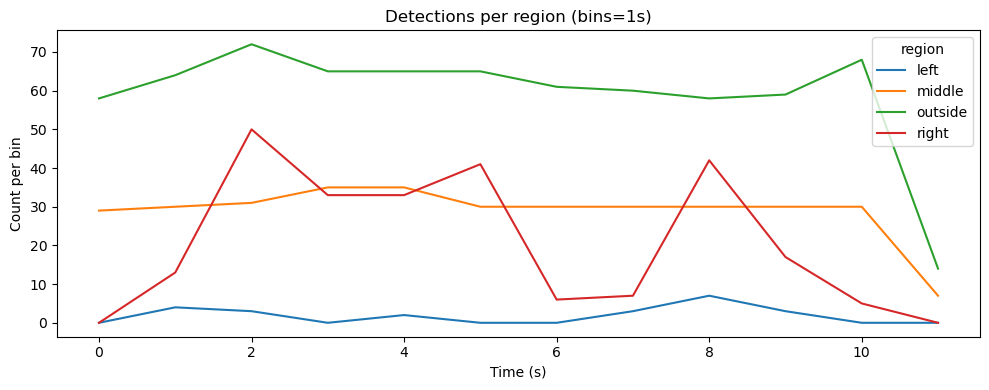

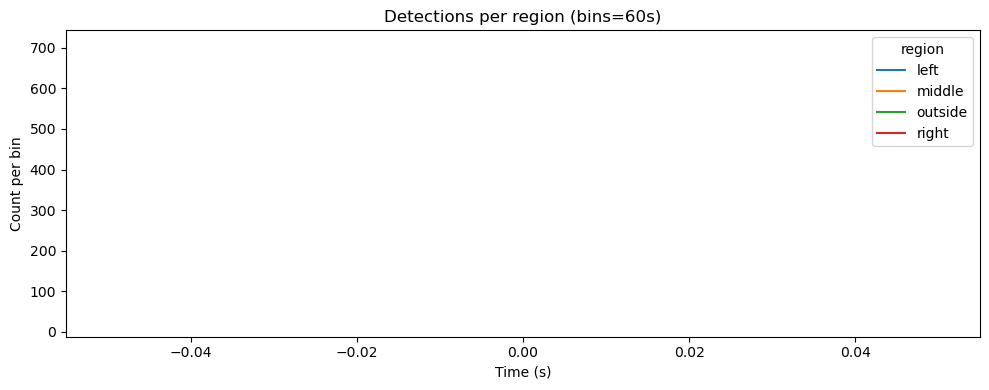

In [28]:
# Apply ROI to detections in-notebook and plot rates by region
import io, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data'
FIGURES_DIR = ROOT / 'figures'
VIDEO_DIR = ROOT / 'video'

# Inputs
csv_path = DATA_DIR / 'processed' / f'{Path(video_name).stem}_streaks.csv'
roi_json_path = DATA_DIR / 'config' / f'{Path(video_name).stem}_rois.json'

# Load detections (skip preamble)
with open(csv_path, 'r') as f:
    lines = f.readlines()
header_idx = 0
for i, line in enumerate(lines[:100]):
    if line.lower().startswith('frame,'):
        header_idx = i
        break

df = pd.read_csv(io.StringIO(''.join(lines[header_idx:])))

# Determine scale used by analyzer (from variable if available, else from preamble)
try:
    scale_used = float(analyze_scale)
except NameError:
    # parse from preamble line 2 (metadata values)
    meta_vals = lines[1].strip().split(',') if len(lines) > 1 else []
    scale_used = float(meta_vals[3]) if len(meta_vals) >= 4 else 1.0

# Load ROI JSON (rects in original pixels)
with open(roi_json_path, 'r') as f:
    roi_cfg = json.load(f)
orig_w = int(roi_cfg['original_size']['width'])
orig_h = int(roi_cfg['original_size']['height'])
rects = roi_cfg['rects']

# Scale ROIs to detection coordinate space (scaled by scale_used)
scaled_rects = []
for r in rects:
    scaled_rects.append({
        'label': r['label'],
        'x': int(round(r['x'] * scale_used)),
        'y': int(round(r['y'] * scale_used)),
        'w': int(round(r['w'] * scale_used)),
        'h': int(round(r['h'] * scale_used)),
    })

# Assign region per detection
labels = []
for _, row in df.iterrows():
    cx, cy = float(row['cx']), float(row['cy'])
    lab = 'outside'
    for r in scaled_rects:
        if (cx >= r['x'] and cx < r['x'] + r['w'] and cy >= r['y'] and cy < r['y'] + r['h']):
            lab = r['label']
            break
    labels.append(lab)

df['region'] = labels

# Totals per region
region_totals = df.groupby('region').size().sort_values(ascending=False)
print('Totals per region:\n', region_totals)

# Plot bin counts at 1s and 60s
for bin_seconds in (1.0, 60.0):
    dfb = df.copy()
    dfb['time_bin'] = (dfb['time_s'] // bin_seconds) * bin_seconds
    counts = dfb.groupby(['region', 'time_bin']).size().reset_index(name='count')
    pivot = counts.pivot(index='time_bin', columns='region', values='count').fillna(0)
    plt.figure(figsize=(10, 4))
    pivot.plot(ax=plt.gca())
    plt.title(f'Detections per region (bins={bin_seconds:.0f}s)')
    plt.xlabel('Time (s)')
    plt.ylabel('Count per bin')
    plt.tight_layout()
    plt.show()